<a href="https://colab.research.google.com/github/RaihahMahmud/FlyRank-AI--starter-ML-Internship-/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question



### Research question

Which content pages should be prioritized for human review based on observed search-performance signals such as impressions, CTR, and average search position?

### Decision supported

The goal is to help content editors decide which pages are worth reviewing first.

This is a **ranking and decision-support problem**. The model does not decide automatically whether a page should be refreshed. Instead, it produces a ranked list that a human reviewer can use to decide which pages deserve closer attention.


## 2. Data


This study uses the **March 2026 FlyRank internship warehouse release**, specifically the `fact_content_daily_performance` table for March 2026.

The raw dataset contains **9,841,378 daily records**, covering **31 reporting dates** and **55 clients**.

For this project, the data was aggregated to the `client_hash_id` + `content_hash_id` level. The model uses three observed Google Search Console signals:

- `gsc_impressions`
- `ctr`, calculated from clicks divided by impressions
- `gsc_avg_position`

Rows missing impressions or clicks were excluded because CTR could not be calculated reliably. Rows still missing a required model feature after aggregation were also excluded.

After filtering, the modeling dataset contains **176,738 content-page records**.

The data is public-safe for this project: client and content identifiers remain pseudonymous, and no client names, domains, URLs, search queries, or credentials are included.

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
from huggingface_hub import login, hf_hub_download
from google.colab import userdata

# Authenticate with Hugging Face
HF_TOKEN = userdata.get("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found in Colab Secrets.")

login(token=HF_TOKEN, add_to_git_credential=False)

# Download March 2026 warehouse file locally
local_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=HF_TOKEN
)

# Load data
con = duckdb.connect()
march = con.sql(
    f"SELECT * FROM read_parquet('{local_file}')"
).df()

# Keep the fields used by the model
df = march[[
    "client_hash_id",
    "content_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]].copy()

# Remove rows where CTR cannot be reliably calculated
df = df.dropna(subset=["gsc_impressions", "gsc_clicks"])

# Calculate CTR
df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    0
)

# Aggregate daily records to client + content page level
base = (
    df.groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg({
        "gsc_impressions": "sum",
        "gsc_clicks": "sum",
        "ctr": "mean",
        "gsc_avg_position": "mean"
    })
)

# Keep complete modeling rows
base = base.dropna(
    subset=["gsc_impressions", "ctr", "gsc_avg_position"]
).copy()

print("DATA SUMMARY")
print("------------")
print("Raw rows:", len(march))
print("Reporting dates:", march["report_date"].nunique())
print("Raw clients:", march["client_hash_id"].nunique())
print("Modeling rows:", len(base))
print("Modeling clients:", base["client_hash_id"].nunique())
print("Modeling columns:", list(base.columns))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DATA SUMMARY
------------
Raw rows: 9841378
Reporting dates: 31
Raw clients: 55
Modeling rows: 176738
Modeling clients: 47
Modeling columns: ['client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_clicks', 'ctr', 'gsc_avg_position']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Features

The model uses three observed search-performance features:

- `gsc_impressions`
- `ctr`
- `gsc_avg_position`

CTR is calculated as clicks divided by impressions.

### Target

The target is based on observed click volume. A page is labeled positive when its aggregated clicks are above the **training-set median**.

This is a proxy for identifying pages with stronger observed click-volume patterns. It is not a label for whether a page should actually be refreshed.

### Model

I use **Logistic Regression** with standardization.

The model produces a score for each page. Pages with higher scores are placed earlier in the review queue.

### Baseline

The baseline flags pages with:

- impressions at or above the training-set 75th percentile, and
- CTR at or below the training-set 25th percentile.

This provides a simple rule-based comparison against the model.

### Validation design

The data is split by `client_hash_id` using an 80/20 grouped split.

This keeps clients completely separate between training and test data. The click threshold and baseline thresholds are learned from the training data only and then applied to the held-out test clients.

### Leakage checks

The model does not use future-window features. Train and test have zero client overlap, and test data is not used to learn the target or baseline thresholds.

In [2]:
  from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Honest client-grouped split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(base, groups=base["client_hash_id"])
)

train = base.iloc[train_idx].copy()
test = base.iloc[test_idx].copy()


click_threshold = train["gsc_clicks"].median()
imp_threshold = train["gsc_impressions"].quantile(0.75)
ctr_threshold = train["ctr"].quantile(0.25)

# Create target
train["target"] = (
    train["gsc_clicks"] > click_threshold
).astype(int)

test["target"] = (
    test["gsc_clicks"] > click_threshold
).astype(int)

# Model features
feature_cols = [
    "gsc_impressions",
    "ctr",
    "gsc_avg_position"
]

# Log Regression pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(
    train[feature_cols],
    train["target"]
)

# Model predictions
test["prediction"] = model.predict(
    test[feature_cols]
)

# Baseline predictions
test["baseline_prediction"] = (
    (test["gsc_impressions"] >= imp_threshold) &
    (test["ctr"] <= ctr_threshold)
).astype(int)

# Metrics
results = pd.DataFrame({
    "Method": [
        "Logistic Regression",
        "Rule-based baseline"
    ],
    "Precision": [
        precision_score(test["target"], test["prediction"], zero_division=0),
        precision_score(test["target"], test["baseline_prediction"], zero_division=0)
    ],
    "Recall": [
        recall_score(test["target"], test["prediction"], zero_division=0),
        recall_score(test["target"], test["baseline_prediction"], zero_division=0)
    ],
    "F1": [
        f1_score(test["target"], test["prediction"], zero_division=0),
        f1_score(test["target"], test["baseline_prediction"], zero_division=0)
    ]
})

print("HONEST VALIDATION")
print("-----------------")
print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train clients:", train["client_hash_id"].nunique())
print("Test clients:", test["client_hash_id"].nunique())
print("Client overlap:", len(
    set(train["client_hash_id"]) &
    set(test["client_hash_id"])
))

display(results.round(4))

HONEST VALIDATION
-----------------
Train rows: 138310
Test rows: 38428
Train clients: 37
Test clients: 10
Client overlap: 0


,Method,Precision,Recall,F1
0,Logistic Regression,0.9993,0.9863,0.9927
1,Rule-based baseline,0.0000,0.0000,0.0000


## 4. Results (vs baseline)


The Logistic Regression model performed substantially better than the simple rule-based baseline on the same held-out client test set.

| Method | Precision | Recall | F1 |
|---|---:|---:|---:|
| Logistic Regression | 0.9993 | 0.9863 | 0.9927 |
| Rule-based baseline | 0.0000 | 0.0000 | 0.0000 |

The Logistic Regression model correctly identified most of the positive cases under the observed click-volume target, while the baseline did not identify positive cases on this test split.

These results show that the model reproduces the observed target pattern much better than the simple baseline under this validation setup. They do **not** show that refreshing a page will improve its future search performance.

,Method,Precision,Recall,F1
0,Logistic Regression,0.9993,0.9863,0.9927
1,Rule-based baseline,0.0000,0.0000,0.0000


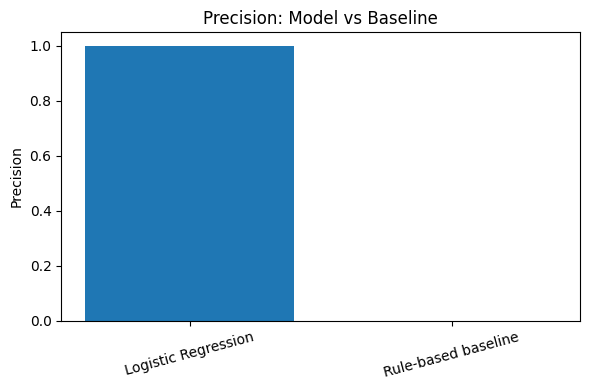

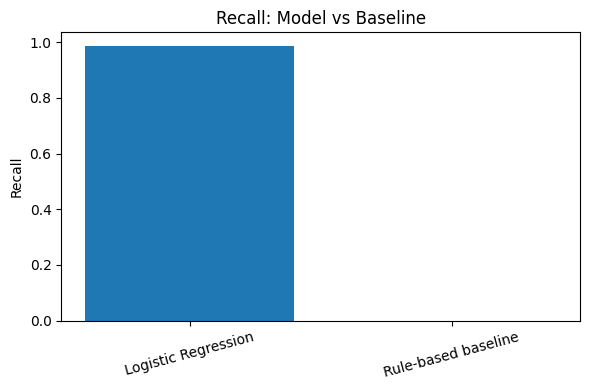

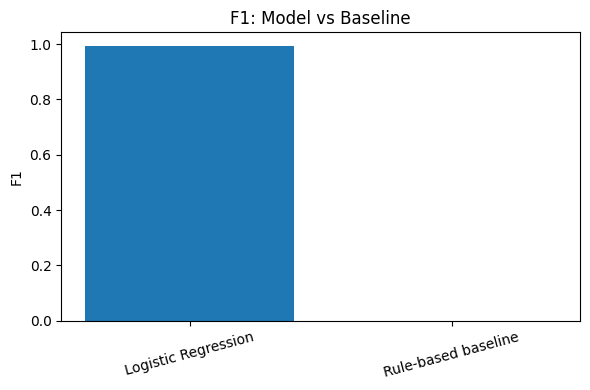

In [3]:
import matplotlib.pyplot as plt

display(results.round(4))

# Plotting model vs baseline
metrics_to_plot = ["Precision", "Recall", "F1"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(results["Method"], results[metric])
    plt.ylabel(metric)
    plt.title(f"{metric}: Model vs Baseline")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 5. Limitations

This model has several important limitations.

- The target is based on observed click volume, so it is a proxy rather than a direct measure of whether a page should be refreshed.
- The model uses historical search-performance signals and does not prove that refreshing a page will improve future clicks, impressions, CTR, or search position.
- The model was validated on held-out clients, but the evaluation still comes from historical data and may not represent future traffic or content conditions.
- The baseline performed poorly on this particular test split, so the comparison should not be interpreted as proof that Logistic Regression is better than every possible rule-based approach.
- Only three search-performance features were used: impressions, CTR, and average position. Other useful content or engagement signals were not included.
- The ranking should therefore be treated as a prioritization signal for human review, not as an automatic decision system.

## 6. Ranked recommendations

The ranked queue is intended to help content editors decide which pages to review first.

### Recommended review order

1. **CTR opportunity** — Review pages with relatively high impressions and low observed CTR first. Check whether the title, snippet, search intent, or page content provides a clear improvement opportunity.
2. **High impressions** — Review pages with strong visibility because changes to these pages may be worth investigating even when CTR is not especially low.
3. **Low CTR** — Investigate pages with low observed CTR relative to the training-set threshold and check whether the page matches the search intent.
4. **Monitor** — Keep pages without a strong signal under observation rather than prioritizing them immediately.

### Human review

The model score and reason code should be used as a starting point for review. Before taking action, an editor should check the page's relevance, search intent, current content, recent changes, and data quality.

A high ranking does not mean that a page must be refreshed. The final decision remains with the human reviewer.

### No-go actions

The model should not be used to automatically publish changes, make autonomous refresh decisions, or claim that a refresh will cause higher clicks, impressions, CTR, or search rankings.

# Ranked review queue

In [4]:

train["model_score"] = model.predict_proba(
    train[feature_cols]
)[:, 1]

test["model_score"] = model.predict_proba(
    test[feature_cols]
)[:, 1]

test["reason_code"] = np.select(
    [
        (test["gsc_impressions"] >= imp_threshold) &
        (test["ctr"] <= ctr_threshold),
        test["gsc_impressions"] >= imp_threshold,
        test["ctr"] <= ctr_threshold
    ],
    [
        "CTR_OPPORTUNITY",
        "HIGH_IMPRESSIONS",
        "LOW_CTR"
    ],
    default="MONITOR"
)

ranked_queue = (
    test[
        [
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "reason_code",
            "gsc_impressions",
            "ctr",
            "gsc_avg_position"
        ]
    ]
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue["priority_rank"] = (
    ranked_queue.index + 1
)

print("RANKED REVIEW QUEUE")
print("-------------------")
print("Pages ranked:", len(ranked_queue))

display(ranked_queue.head(20))

RANKED REVIEW QUEUE
-------------------
Pages ranked: 38428


,client_hash_id,content_hash_id,model_score,reason_code,gsc_impressions,ctr,gsc_avg_position,priority_rank
0,client_0fa64a184f18a4a0,content_04b7abe75a1b84f7,1.0,HIGH_IMPRESSIONS,7598,0.003528,2.829824,1
1,client_0fa64a184f18a4a0,content_04470db293f90bb6,1.0,MONITOR,26,0.050000,4.445833,2
2,client_0fa64a184f18a4a0,content_03d0e7e082bff05d,1.0,HIGH_IMPRESSIONS,2465,0.009445,2.254088,3
3,client_73cda7b4e4f265ea,content_1738b8ef16a2261b,1.0,HIGH_IMPRESSIONS,2767,0.005548,6.789972,4
4,client_73cda7b4e4f265ea,content_e5e818bc0694217f,1.0,HIGH_IMPRESSIONS,2127,0.005366,4.598878,5
5,client_73cda7b4e4f265ea,content_e5e687493c486444,1.0,MONITOR,683,0.006531,2.658016,6
6,client_73cda7b4e4f265ea,content_16d1a9b9b4b0b793,1.0,MONITOR,361,0.006452,12.626774,7
7,client_73cda7b4e4f265ea,content_1716da1a70d3c6f6,1.0,HIGH_IMPRESSIONS,3299,0.007532,2.779290,8
8,client_73cda7b4e4f265ea,content_17154410fb51d179,1.0,MONITOR,126,0.016129,28.846421,9
9,client_73cda7b4e4f265ea,content_1714a388d996f68e,1.0,HIGH_IMPRESSIONS,1000,0.004734,4.292338,10


## 7. Artifacts the paper embeds


The main artifacts produced by this notebook are:

1. **Model vs baseline metrics** — Precision, Recall, and F1 on the same held-out client test set.
2. **Metric comparison charts** — Visual comparison of Logistic Regression and the rule-based baseline.
3. **Ranked review queue** — Pages ordered by model score with a reason code and priority rank.
4. **Validation checks** — Client overlap and leakage checks supporting the evaluation design.

These artifacts are intended to support the research paper's results and recommendations while keeping the analysis public-safe.

# Capstone artifact summary


In [5]:

print("CAPSTONE ARTIFACTS")
print("------------------")

print("\nValidation metrics:")
display(results.round(4))

print("\nReason-code distribution:")
display(
    ranked_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

print("\nTop 10 ranked pages:")
display(ranked_queue.head(10))

CAPSTONE ARTIFACTS
------------------

Validation metrics:


,Method,Precision,Recall,F1
0,Logistic Regression,0.9993,0.9863,0.9927
1,Rule-based baseline,0.0000,0.0000,0.0000



Reason-code distribution:


,reason_code,pages
0,LOW_CTR,19727
1,HIGH_IMPRESSIONS,11492
2,MONITOR,6135
3,CTR_OPPORTUNITY,1074



Top 10 ranked pages:


,client_hash_id,content_hash_id,model_score,reason_code,gsc_impressions,ctr,gsc_avg_position,priority_rank
0,client_0fa64a184f18a4a0,content_04b7abe75a1b84f7,1.0,HIGH_IMPRESSIONS,7598,0.003528,2.829824,1
1,client_0fa64a184f18a4a0,content_04470db293f90bb6,1.0,MONITOR,26,0.050000,4.445833,2
2,client_0fa64a184f18a4a0,content_03d0e7e082bff05d,1.0,HIGH_IMPRESSIONS,2465,0.009445,2.254088,3
3,client_73cda7b4e4f265ea,content_1738b8ef16a2261b,1.0,HIGH_IMPRESSIONS,2767,0.005548,6.789972,4
4,client_73cda7b4e4f265ea,content_e5e818bc0694217f,1.0,HIGH_IMPRESSIONS,2127,0.005366,4.598878,5
5,client_73cda7b4e4f265ea,content_e5e687493c486444,1.0,MONITOR,683,0.006531,2.658016,6
6,client_73cda7b4e4f265ea,content_16d1a9b9b4b0b793,1.0,MONITOR,361,0.006452,12.626774,7
7,client_73cda7b4e4f265ea,content_1716da1a70d3c6f6,1.0,HIGH_IMPRESSIONS,3299,0.007532,2.779290,8
8,client_73cda7b4e4f265ea,content_17154410fb51d179,1.0,MONITOR,126,0.016129,28.846421,9
9,client_73cda7b4e4f265ea,content_1714a388d996f68e,1.0,HIGH_IMPRESSIONS,1000,0.004734,4.292338,10


## Self-check

Before submission:

- [x] Every capstone section is filled with both written methodology and supporting code where needed.
- [x] The notebook uses the March 2026 FlyRank internship warehouse release.
- [x] The model is Logistic Regression with three observed search-performance features.
- [x] Validation uses a client-grouped 80/20 split with zero client overlap.
- [x] Target and baseline thresholds are learned from training data only.
- [x] No future-window features are used.
- [x] Model results are compared with the baseline on the same held-out test set.
- [x] The ranked queue is presented as decision-support for human review.
- [x] No causal claim is made that refreshing content will improve search performance.
- [x] No client names, domains, URLs, private search queries, or credentials are included.
- [x] The notebook runs from top to bottom without errors.
- [x] The completed notebook is committed under `work/notebooks/capstone.ipynb`.